### Architecture
In this experiments, we applied auxiliary task learning where SWIN transformer extracts a shared 1536-dim(last layer) feature vector. This vector is fed simultaneously into a main head predicting Pawpularity and one or more auxiliary heads predicting BRISQUE quality score and pet visibility ratio. All heads are single linear layers, and the total loss `L = L_paw + 0.1 × L_aux` is backpropagated through the shared backbone in a single pass, forcing it to learn representations useful for both the main task and the semantic auxiliary tasks. The auxiliary label is visiblity ratio


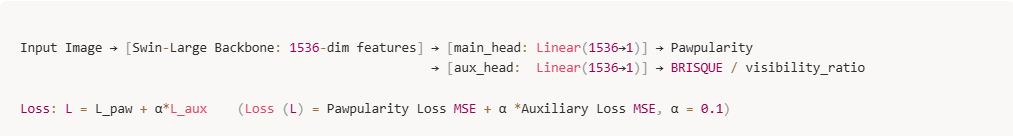


In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [ ]:
# 1: imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../.."
img_folder  = os.path.join(main_folder, "data", "train")
out_dir     = os.path.join(main_folder, "outputs", "extra", "exp15_swin_384_strong_MSE_aux_visibility_normalized")
out_csv     = os.path.join(main_folder, "data", "train_with_visibility.csv")

os.makedirs(out_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#  generate pseudo-labels if not already done, load CSV, set cfg

import sys
sys.path.insert(0, os.path.join(main_folder))
from src.gen_pseudo_labels import generate_pseudo_labels

# --- generate all pseudo-labels (skips if CSV already exists) ---
df_raw = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))

df = generate_pseudo_labels(
    df=df_raw,
    img_folder=img_folder,
    out_csv=out_csv,
    run_brisque=False,
    run_yolo=True,
    force_recompute=False,
)

TARGET = "Pawpularity"
# --- set cfg ---
cfg = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg["img_size"] = 384
cfg["name"]     = "exp15_swin_384_strong_MSE_aux_visibility_normalized"
cfg["loss"]     = "mse"

cfg["aux_tasks"] = ["visibility_ratio"]
cfg["aux_loss_weights"] = {"visibility_ratio": 0.1} 

save_config(cfg, out_dir)
set_seed(cfg["seed"])



Pseudo-label CSV already exists, loading: ../../data/train_with_visibility.csv


Pseudo-label statistics:
       visibility_ratio
count          9912.000
mean              0.476
std               0.251
min               0.000
25%               0.288
50%               0.474
75%               0.670
max               0.999

Correlation with Pawpularity:
  visibility_ratio: r = -0.0202


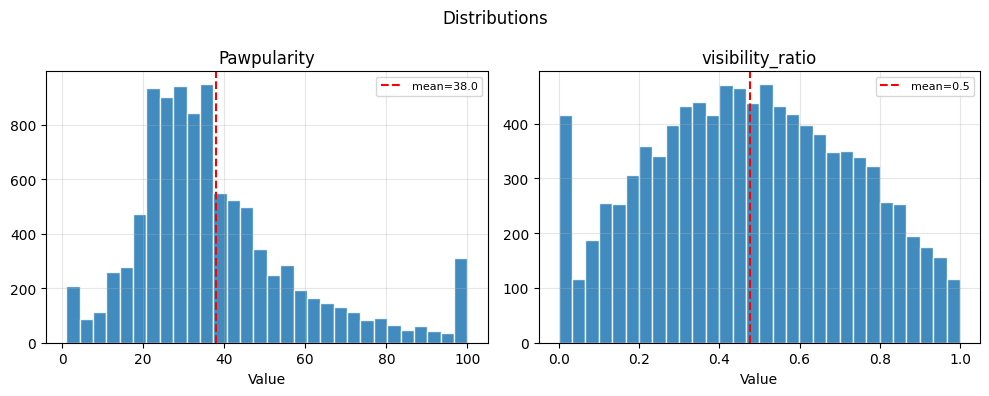

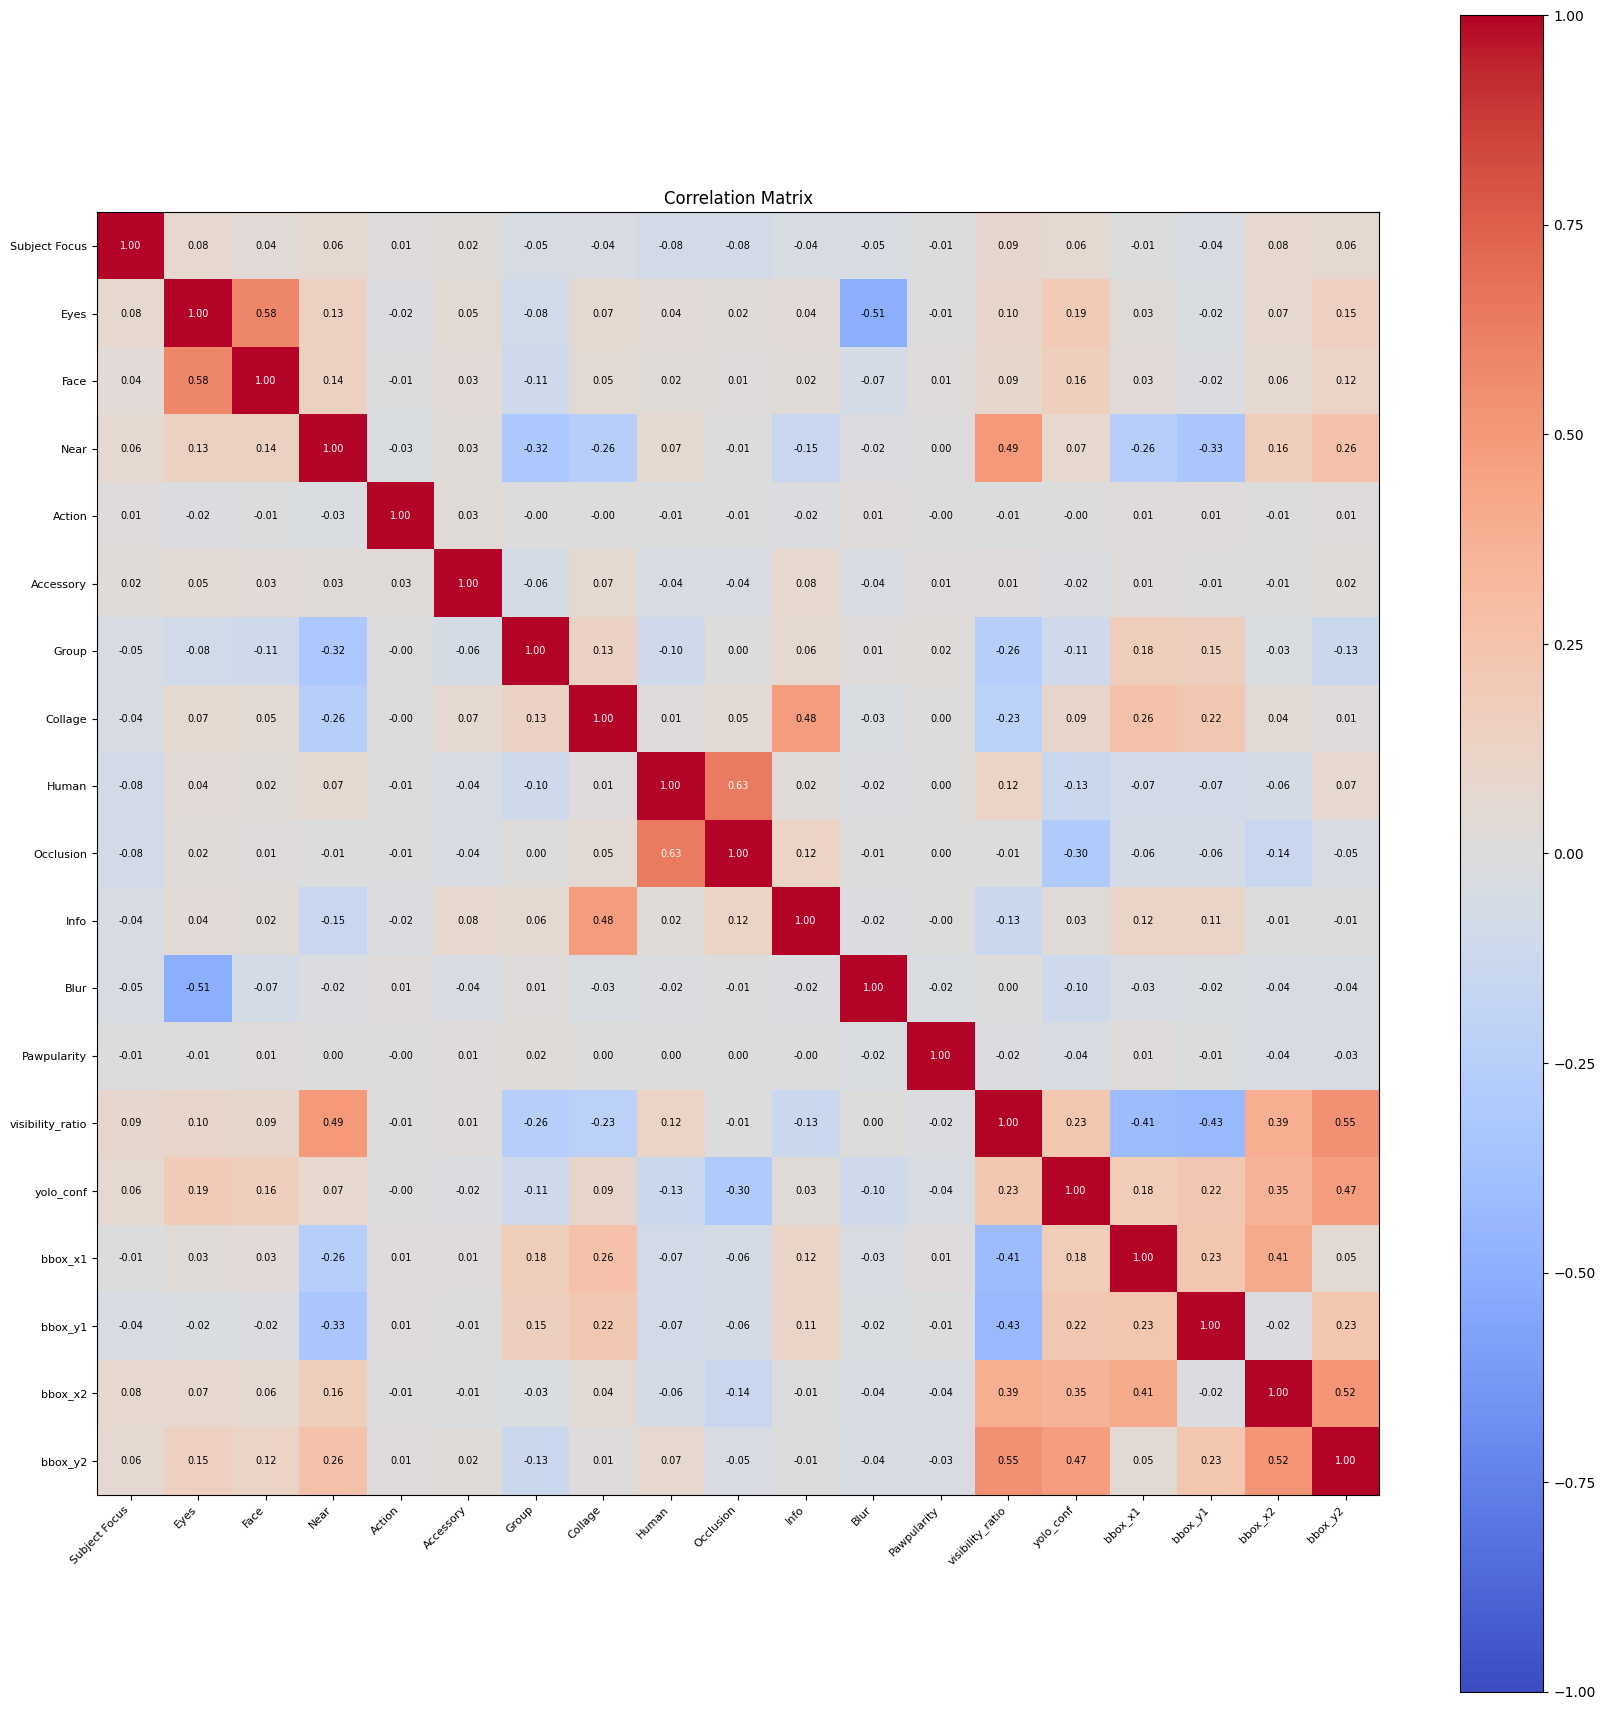

In [ ]:


from src.plot import plot_pseudo_label_analysis

pseudo_cols = [c for c in ["BRISQUE", "visibility_ratio"] if c in df.columns]

# simple stats
print("Pseudo-label statistics:")
print(df[pseudo_cols].describe().round(3))

print("\nCorrelation with Pawpularity:")
for col in pseudo_cols:
    r = df[col].corr(df["Pawpularity"])
    print(f"  {col}: r = {r:.4f}")

# plots
plot_pseudo_label_analysis(
    df=df,
    pseudo_cols=pseudo_cols,
    target_col="Pawpularity",
    out_dir=out_dir,
)

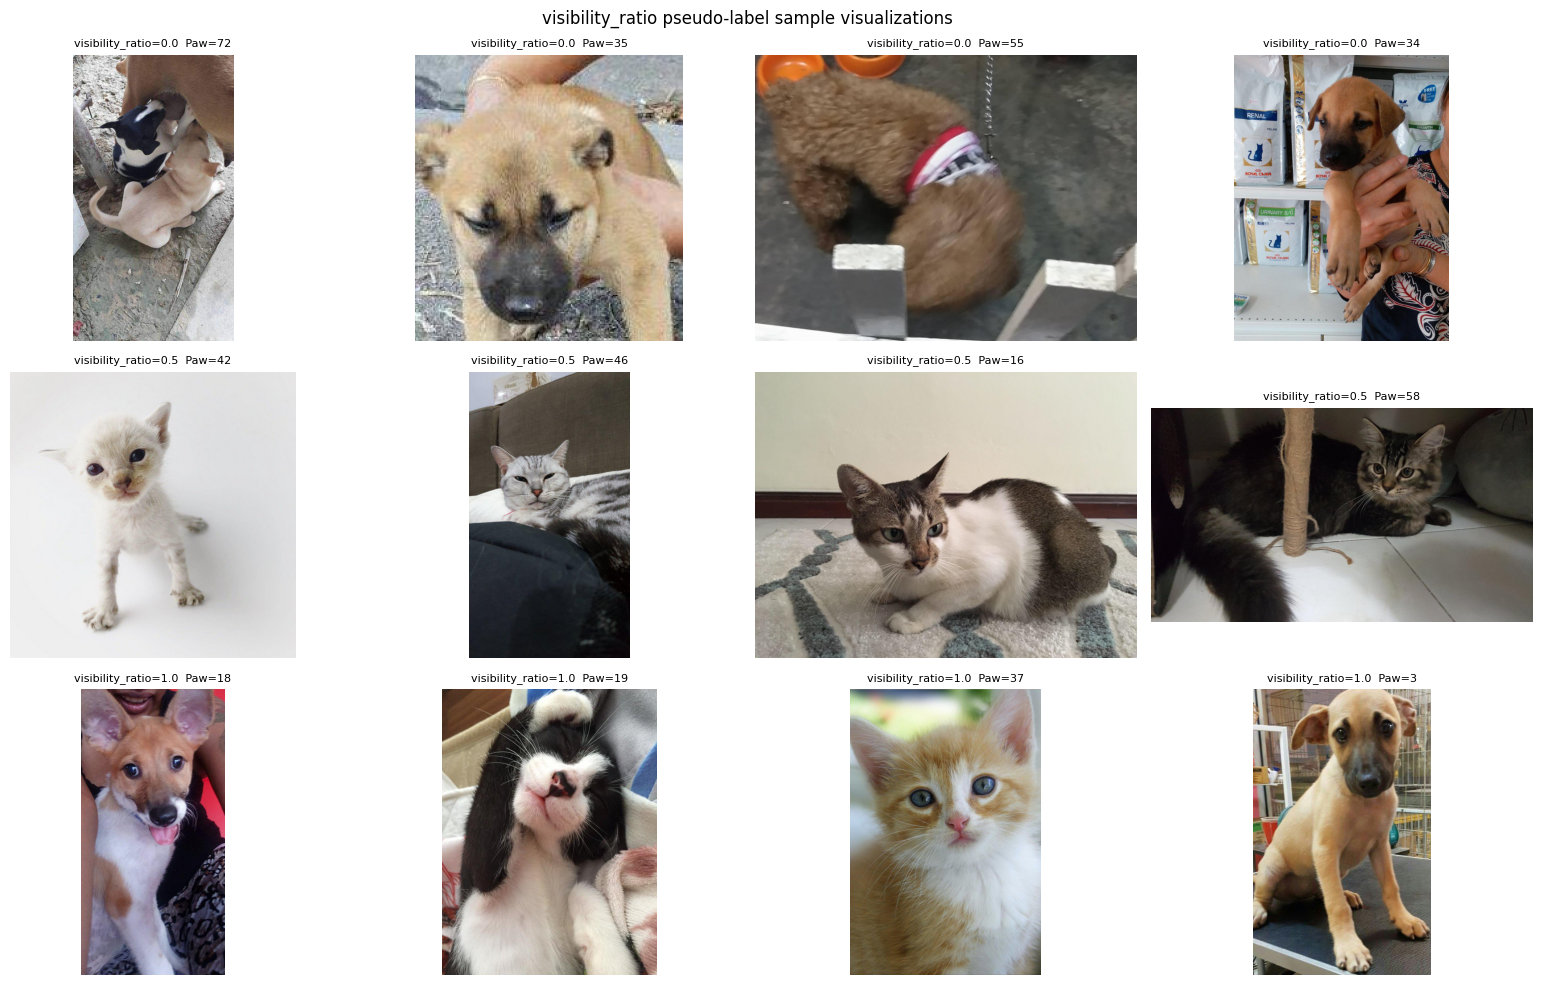

In [ ]:
# sample images — low / mid / high visibility_ratio
# shows the pseudo-label

df_vis = df[["Id", "Pawpularity", "visibility_ratio"]].copy()

low  = df_vis.nsmallest(4, "visibility_ratio")
mid  = df_vis.iloc[(df_vis["visibility_ratio"] - df_vis["visibility_ratio"].median()).abs().argsort()[:4]]
high = df_vis.nlargest(4, "visibility_ratio")

groups = [
    ("Low visibility_ratio\n(good quality)",  low),
    ("Mid visibility_ratio",                  mid),
    ("High visibility_ratio\n(poor quality)", high),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for row_idx, (group_label, group_df) in enumerate(groups):
    for col_idx, (_, r) in enumerate(group_df.iterrows()):
        ax = axes[row_idx][col_idx]
        img = Image.open(os.path.join(img_folder, r["Id"] + ".jpg")).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"visibility_ratio={r['visibility_ratio']:.1f}  Paw={r['Pawpularity']}", fontsize=8)
    axes[row_idx][0].set_ylabel(group_label, fontsize=9, rotation=0,
                                labelpad=130, va="center")

plt.suptitle("visibility_ratio pseudo-label sample visualizations", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
#  scale visibility_ratio to [0,100] 
df["visibility_ratio"] = df["visibility_ratio"] * 100
print(f"\nvisibility_ratio scaled to [0,100] in memory")
print(df["visibility_ratio"].describe())


visibility_ratio scaled to [0,100] in memory
count    9912.000000
mean       47.635706
std        25.077246
min         0.000000
25%        28.800346
50%        47.443281
75%        67.000692
max        99.928158
Name: visibility_ratio, dtype: float64


In [ ]:

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp15_swin_384_strong_MSE_aux_visibility_normalized: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: PawRMSE=22.8023 TotalLoss=658.5943 | ValRMSE: 21.4218 | visibility_ratio_val_mse: 711.6401
Epoch 2/10 | Fold 1 | Train[MSE]: PawRMSE=20.5280 TotalLoss=490.8280 | ValRMSE: 21.0257 | visibility_ratio_val_mse: 631.3353
Epoch 3/10 | Fold 1 | Train[MSE]: PawRMSE=20.5106 TotalLoss=483.9497 | ValRMSE: 21.0238 | visibility_ratio_val_mse: 630.6290
Epoch 4/10 | Fold 1 | Train[MSE]: PawRMSE=20.5037 TotalLoss=483.1110 | ValRMSE: 21.0240 | visibility_ratio_val_mse: 632.9470
Epoch 5/10 | Fold 1 | Train[MSE]: PawRMSE=20.4892 TotalLoss=471.6248 | ValRMSE: 21.0044 | visibility_ratio_val_mse: 491.1051
Epoch 6/10 | Fold 1 | Train[MSE]: PawRMSE=19.9957 TotalLoss=437.3775 | ValRMSE: 19.8153 | visibility_ratio_val_mse: 333.3671
Epoch 7/10 | Fold 1 | Train[MSE]: PawRMSE=18.9872 TotalLoss=391.4140 | ValRMSE: 19.1497 | visibility_ratio_val_mse: 345.6160
Epoch 8/10 | Fold 1 | Train[MSE]: PawRMSE=18.3103 TotalL

In [ ]:



import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.7848 (n=1983)
Fold 2 OOF RMSE: 18.1739 (n=1983)
Fold 3 OOF RMSE: 17.5510 (n=1982)
Fold 4 OOF RMSE: 18.0335 (n=1982)
Fold 5 OOF RMSE: 18.3687 (n=1982)


In [ ]:
# aux-task validation metrics 



baseline_rmse_path = os.path.join(
    "../..", "outputs", "extra", "exp3_swin_384_strong_MSE", "fold_rmse.npy"
)
aux_rmse_path = os.path.join(out_dir, "fold_rmse.npy")

if os.path.exists(baseline_rmse_path) and os.path.exists(aux_rmse_path):
    fold_rmse_base = np.load(baseline_rmse_path)
    fold_rmse_aux  = np.load(aux_rmse_path)

    print(f"\n{'Model':<35} {'Mean':>7} {'Std':>6}  Fold RMSEs")
    print(f"{'Swin image-only (exp3)':<35} "
          f"{fold_rmse_base.mean():>7.4f} {fold_rmse_base.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_base.tolist()]}")
    print(f"{'Swin + visibility_ratio aux (exp15)':<35} "
          f"{fold_rmse_aux.mean():>7.4f} {fold_rmse_aux.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_aux.tolist()]}")




Model                                  Mean    Std  Fold RMSEs
Swin image-only (exp3)              17.9181 0.3046  [17.8667, 18.1347, 17.4169, 17.8554, 18.3169]
Swin + visibility_ratio aux (exp15) 18.1824 0.4046  [18.7848, 18.1739, 17.551, 18.0335, 18.3687]


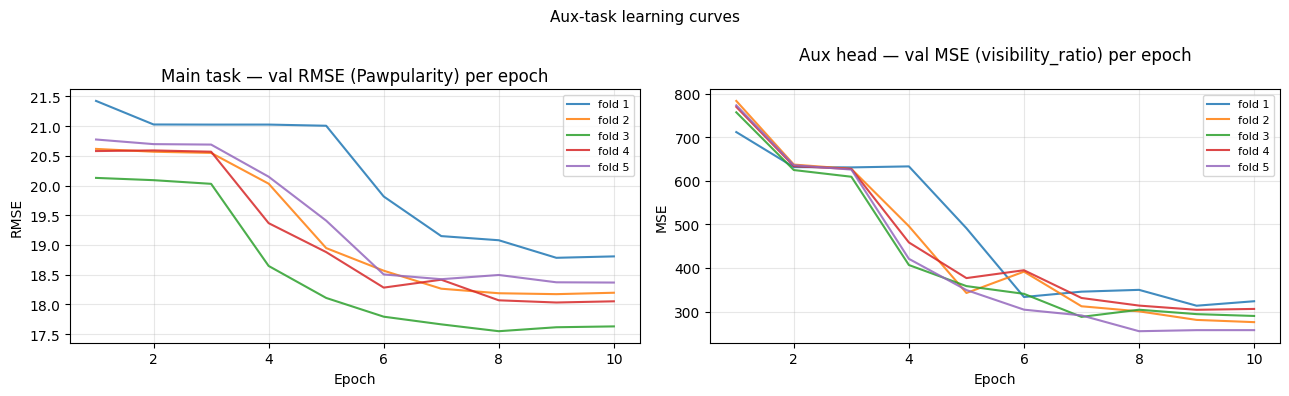

In [ ]:
#  per-epoch BRISQUE val MSE curve
# Aux loss

all_logs = []
for fold in range(1, 6):
    lp = os.path.join(out_dir, f"epoch_logs_fold{fold}.csv")
    if os.path.exists(lp):
        all_logs.append(pd.read_csv(lp))

if all_logs:
    logs_df = pd.concat(all_logs).reset_index(drop=True)

    if "visibility_ratio_val_mse" in logs_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        for fold_i in range(1, 6):
            fold_log = logs_df[logs_df["fold"] == fold_i]
            if fold_log.empty:
                continue
            axes[0].plot(fold_log["epoch"], fold_log["val_rmse"],
                         label=f"fold {fold_i}", alpha=0.85)
            axes[1].plot(fold_log["epoch"], fold_log["visibility_ratio_val_mse"],
                         label=f"fold {fold_i}", alpha=0.85)

        axes[0].set_title("Main task — val RMSE (Pawpularity) per epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("RMSE")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        axes[1].set_title("Aux head — val MSE (visibility_ratio) per epoch\n"
                          )
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MSE")
        axes[1].legend(fontsize=8)
        axes[1].grid(alpha=0.3)

        plt.suptitle("Aux-task learning curves", fontsize=11)
        plt.tight_layout()
        
        plt.show()

#     

In [27]:
logs_df.head()

,fold,epoch,train_loss,train_paw_loss,val_rmse,loss_visibility_ratio,visibility_ratio_val_mse
0,1,1,658.594316,519.943328,21.421822,1386.509870,711.640137
1,1,2,490.828050,421.399885,21.025709,694.281646,631.335327
2,1,3,483.949707,420.684126,21.023771,632.655799,630.629028
3,1,4,483.110963,420.399989,21.024035,627.109734,632.946960
4,1,5,471.624839,419.806363,21.004412,518.184757,491.105072


### Training and Validation Loss Curve

In [17]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs","extra", "exp3_swin_384_strong_MSE")


### Side by Side Comparison with Image baseline

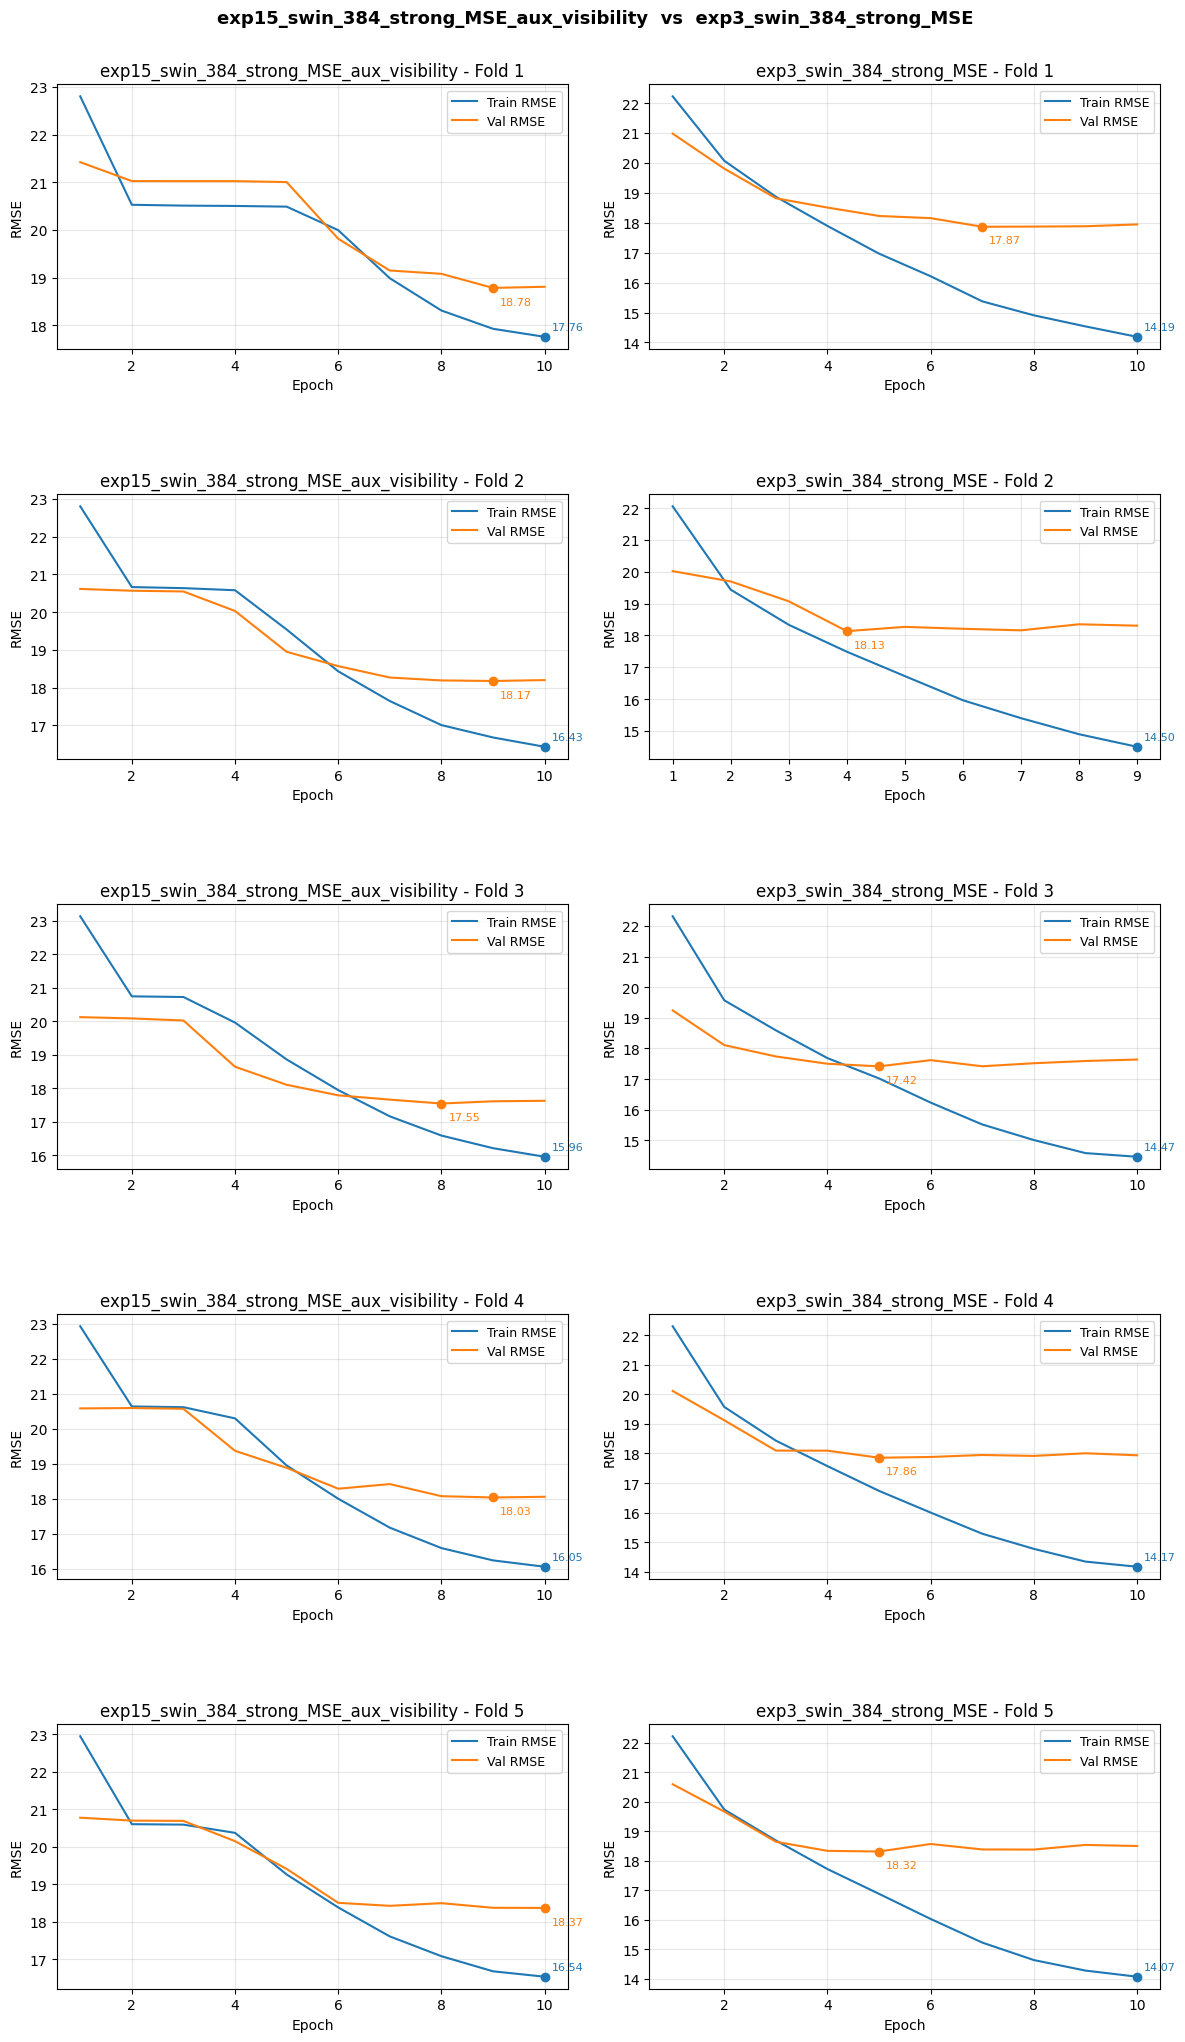

In [18]:
### Side by Side Comparison with Image only
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="exp15_swin_384_strong_MSE_aux_visibility", label_b="exp3_swin_384_strong_MSE")


In [19]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,deb8d1618d0cdc2a78c8198b882ebb2b,3,100,26.712744,73.287256
1,941e532a21f7edb21766e88a15e588cb,4,100,27.331882,72.668118
2,4435d6f98ad72782ca0cf61f946b016d,5,100,27.520620,72.479380
3,9f40aa2a4e04c42f3e3b6e76070f2dea,1,100,28.962667,71.037333
4,48a66727373de4e7fa7bb3331cd9acc8,3,96,25.268351,70.731649


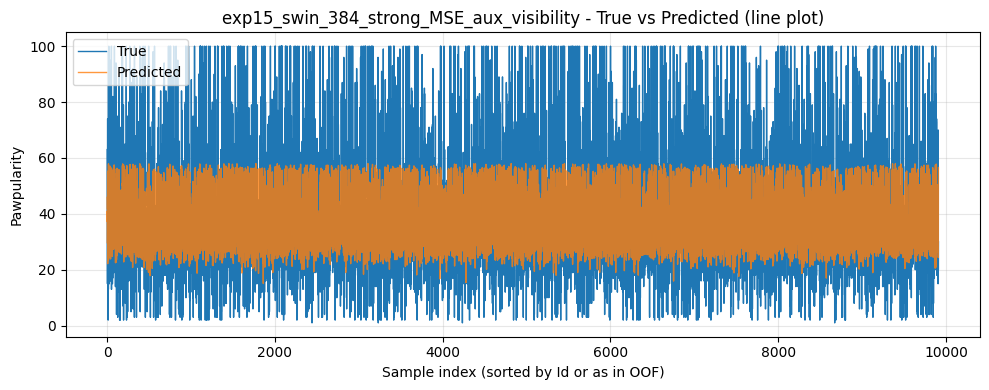

In [20]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="exp15_swin_384_strong_MSE_aux_visibility")





exp15_swin_384_strong_MSE_aux_visibility OOF RMSE: 18.186944440010812
exp3_swin_384_strong_MSE OOF RMSE: 17.920736475104714
ΔRMSE (exp3_swin_384_strong_MSE - exp15_swin_384_strong_MSE_aux_visibility): -0.26620796490609777


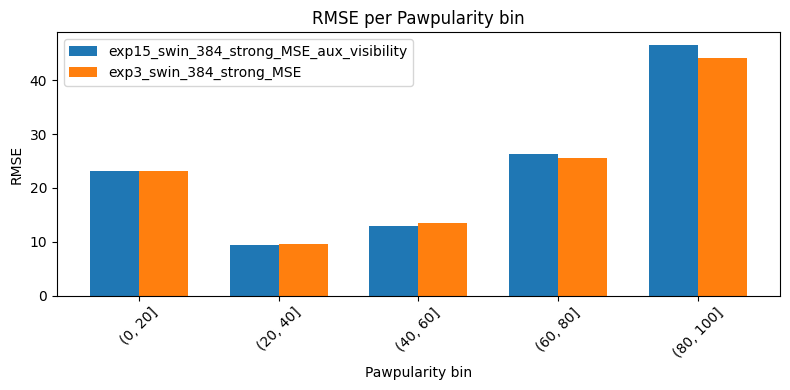

In [21]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="exp15_swin_384_strong_MSE_aux_visibility",
    label_b="exp3_swin_384_strong_MSE",
    title_prefix="",
)

In [22]:
df_bins.head()

,bin,count,exp15_swin_384_strong_MSE_aux_visibility_rmse,exp3_swin_384_strong_MSE_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.206858,23.184814,-0.022044,exp3_swin_384_strong_MSE_better
1,"(20, 40]",5119,9.341324,9.621530,0.280206,exp15_swin_384_strong_MSE_aux_visibility_better
2,"(40, 60]",2088,13.009798,13.566323,0.556526,exp15_swin_384_strong_MSE_aux_visibility_better
3,"(60, 80]",727,26.237826,25.544517,-0.693309,exp3_swin_384_strong_MSE_better
4,"(80, 100]",561,46.534665,44.059252,-2.475413,exp3_swin_384_strong_MSE_better


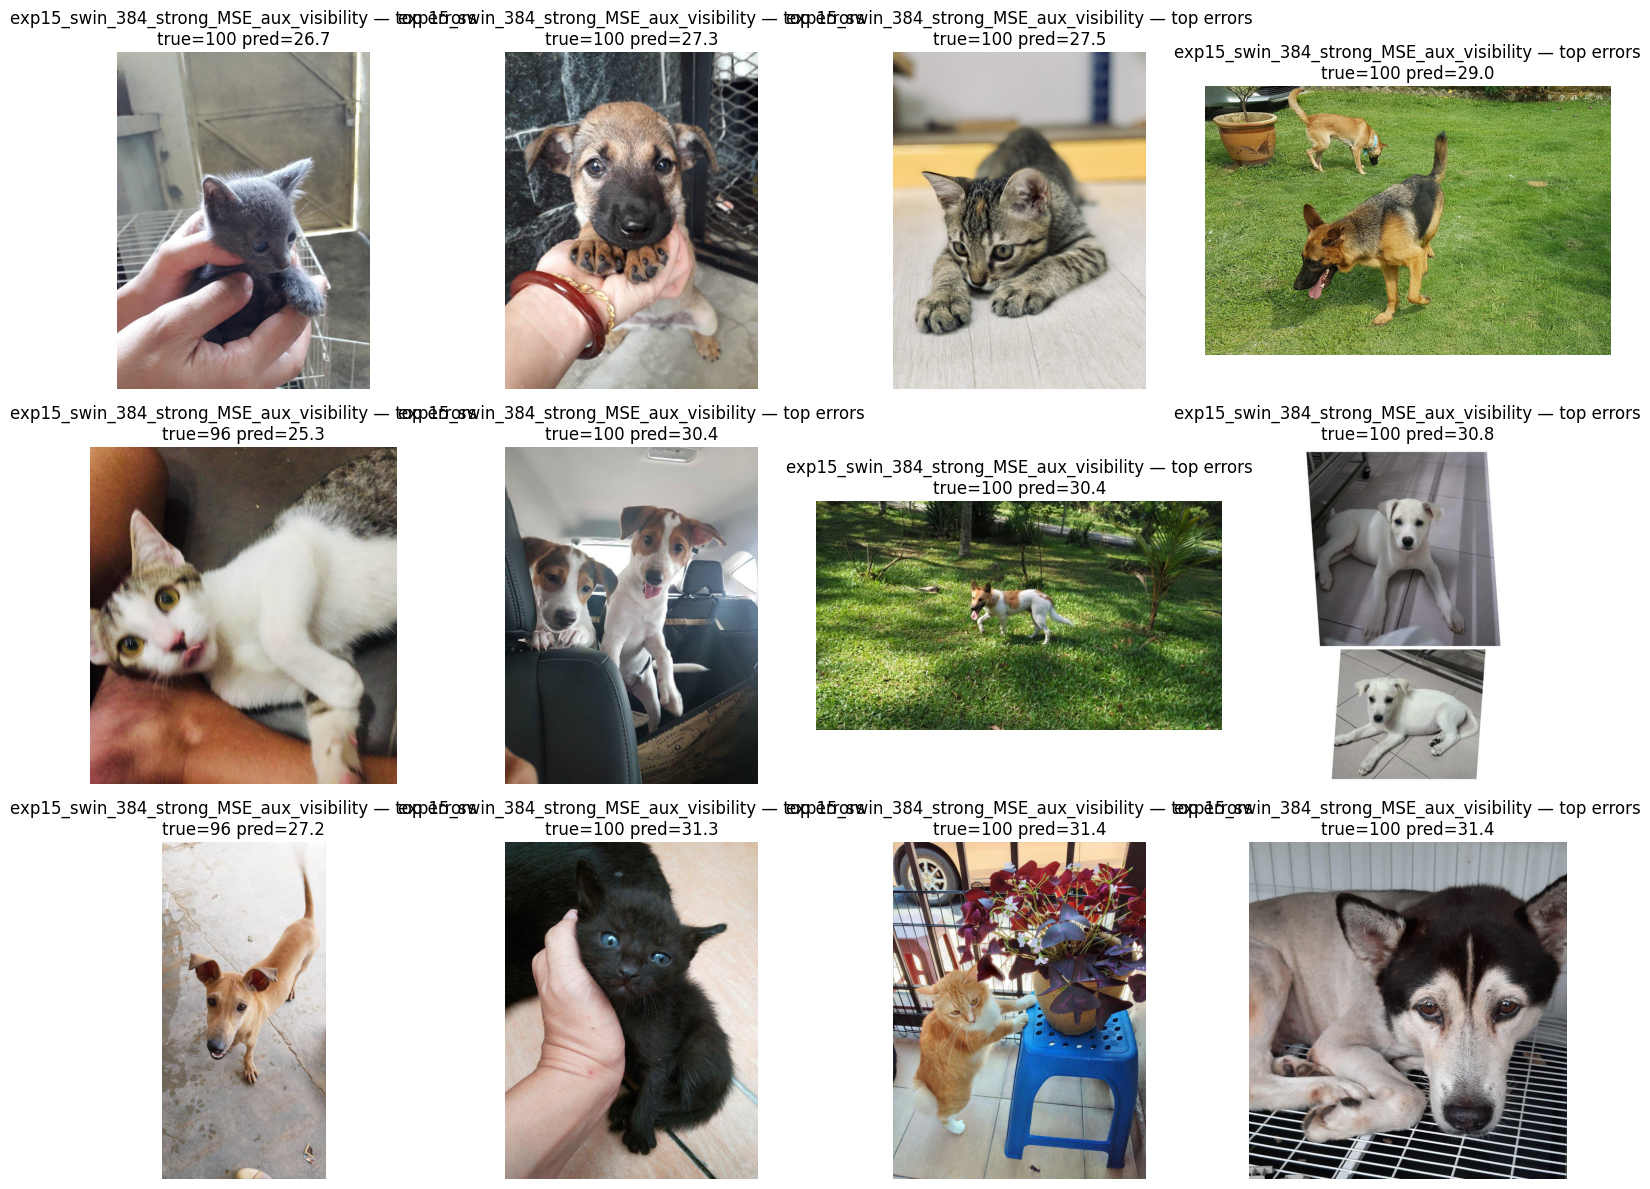

In [23]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp15_swin_384_strong_MSE_aux_visibility — top errors")

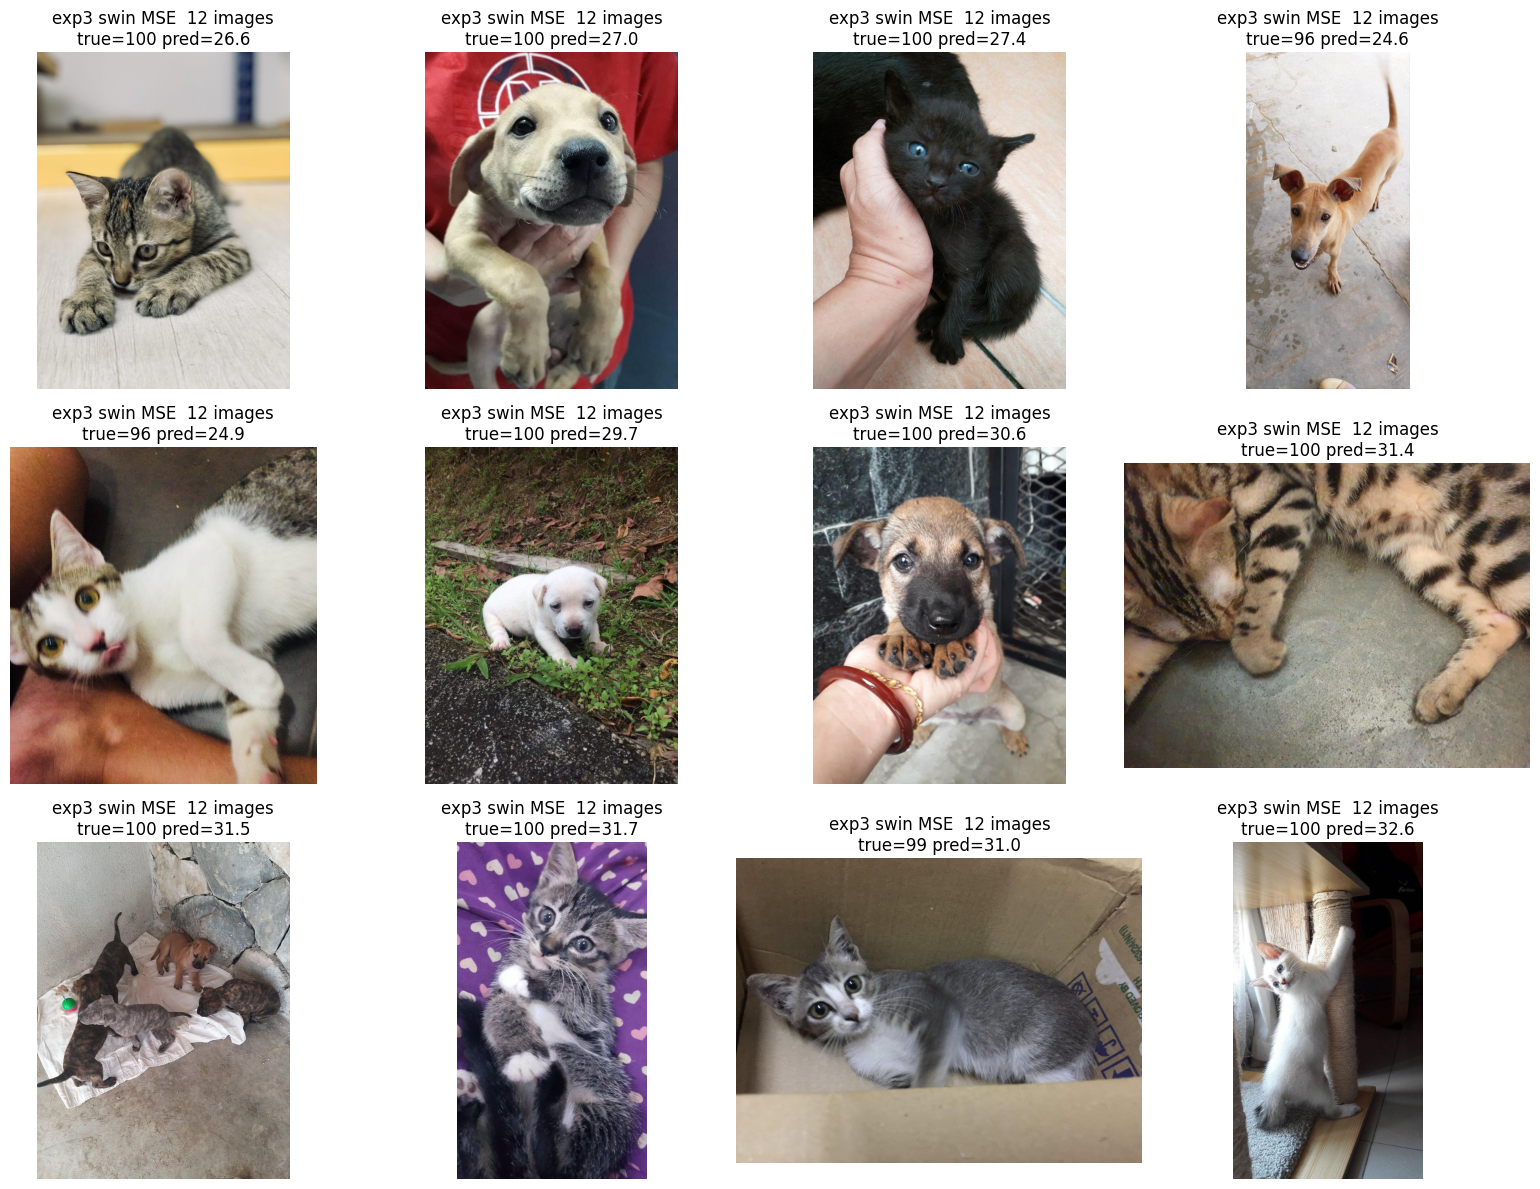

In [24]:
# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp3 swin MSE  12 images")